# Simulation of a silicon solar cell

The following code loads the needed modules.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import calc_p_density, calc_n_density, calc_recombination

import synumses.one_dimension.solver as solver

## Definition of the solar cell
The silicon has a thickness of $l_\mathrm{x}=1\,\mathrm{\mu m}$ and the pn junction is at $x=40\,\mathrm{nm}$.<br>
The p-doping is much higer compared to th n-doping.<br>
There is no recombination.

In [2]:
parameters.n = 1000
parameters.lx = 1000E-9

parameters.init_geometry()

#parameters.Cau = 0*1E-24

Na = 1.0E24
Nd = 4.0E22

Eg = 1.12

# pn transistion at x1
x1 = 40E-9

for i in range(0, parameters.n):
    
    parameters.Ec[i] = Eg
    parameters.Ev[i] = 0
    
    if parameters.pos_x[i] < x1:
        
        parameters.C[i]  = -Na
    else:       
        parameters.C[i]  = Nd

Now, we plot the default band diagramm and the doping levels

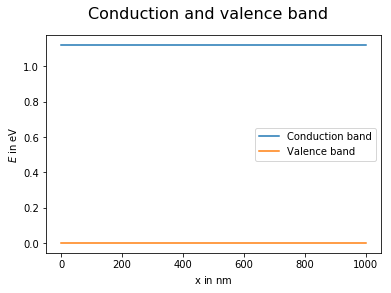

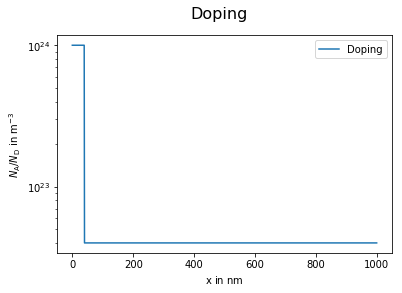

In [3]:
# Band diagramm
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.Ec, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, parameters.Ev, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

# Doping level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


## Solving without biasing
Now, let's apply a voltage of $0\,\mathrm{mV}$!.

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


Norm of b:  3.6772333653904377
Norm of x: 1.466945812425527e-09


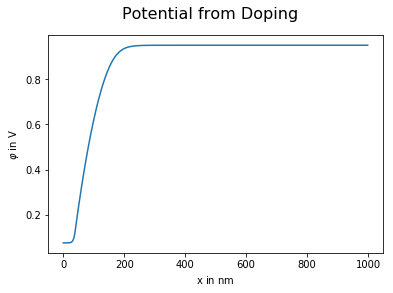

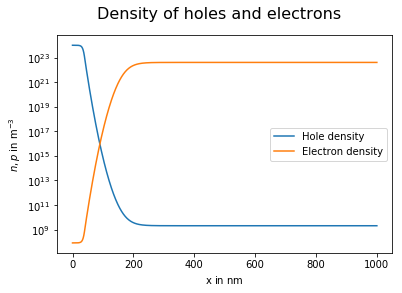

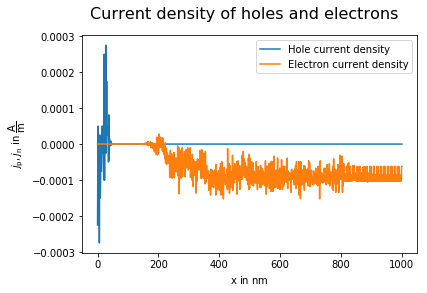

In [4]:
parameters.init_potential()

solver.solve_no_bias()
bias_point = 0.0

solver.solve_bias(bias_point,0)

# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

axis.plot(parameters.u[0::3], label='Potential')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

plt.show()


# Quasi fermi levels of electrons and holes
#fig, axis = plt.subplots(1,1, sharey=True)
#fig.suptitle("Quasi fermi levels of holes and electrons", fontsize=16)

#axis.plot(parameters.u[1::3], label='Quasi fermi levels of hole')
#axis.plot(parameters.u[2::3], label='Quasi fermi levels of electrons')
#axis.legend()
#plt.show()



# Electron and hole density
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n,p$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
plt.show()

## Simulation with illumination
Now we illuminate the solar cell and simulate the short circuit current density.<br>
We assume a powerdensity of $1\,\mathrm{\dfrac{kW}{m^3}}$,
an absorption coefficient for silicon of $\alpha_\mathrm{Si} = 2.0\cdot 10^{6}\,\mathrm{m^{-1}}$, and
a light efficiency of $\eta = 0.6$. <br>
For the simulation to converge, the illumination must be ramped up, this takes some time.<br>


In [5]:
# For the simulatoin the illumination starts
# 10nm after and stops 10nm before the contacts.
x1 = 10E-9
x2 = 990E-9


bias_point = 0.0

eta = 0.6

I0 = 1E3

alpha = 2E6

dI0 = alpha*I0*eta

steps = 23

for i in range(steps):

    print("Step:", i,
          "Generation rate at the surface",
          dI0/(2**steps) * 2**(i+1) /(parameters.q * Eg))

    parameters.generation = np.where((parameters.pos_x  > x1) & (parameters.pos_x < x2),
                                     dI0/(2**steps) * 2**(i+1) * np.exp(-parameters.pos_x*alpha) /(parameters.q * Eg),
                                     0)

    solver.solve_bias(-bias_point,0)
    
    j = np.mean(hole_current_density() + electron_current_density())
    
    print("\t Current density:", j)
    

Step: 0 Generation rate at the surface 1.596552985055106e+21
Norm of b:  0.0014534887502649894
Norm of x: 9.32704959379715
Norm of b:  32.11813754779956
Norm of x: 0.7040840531717977
Norm of b:  11.815602575566496
Norm of x: 0.6882922323056687
Norm of b:  4.346717507576848
Norm of x: 0.6719287977749385
Norm of b:  1.5990686236207996
Norm of x: 0.6548570205580431
Norm of b:  0.5882660349156815
Norm of x: 0.6368958554139703
Norm of b:  0.21641653151762427
Norm of x: 0.6177548388505278
Norm of b:  0.07962909310035678
Norm of x: 0.5970459719460968
Norm of b:  0.029326830776765456
Norm of x: 0.574240698244424
Norm of b:  0.01088651195397079
Norm of x: 0.5485680289078978
Norm of b:  0.004241441132862951
Norm of x: 0.5188179380129581
Norm of b:  0.002104873848658728
Norm of x: 0.48296899422676165
Norm of b:  0.0016009171875521562
Norm of x: 0.43751506931282785
Norm of b:  0.0014765099678098112
Norm of x: 0.37649258116983786
Norm of b:  0.0014852572889622777
Norm of x: 0.29145406979133204
Norm

## Plot the parameters with illumination
* generation rate,
* hole and electron density, and
* hole and electron current density.

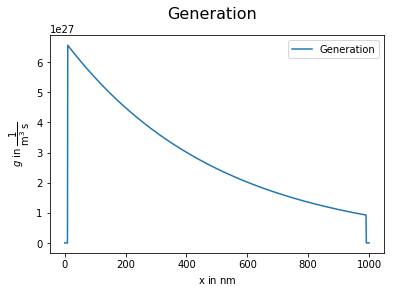

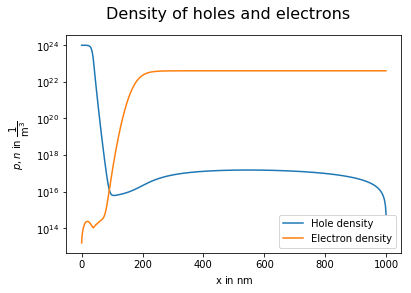

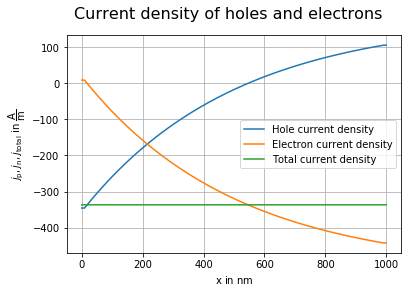

In [6]:
# Generation
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Generation", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.generation, label='Generation')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$g$ in $\mathrm{\dfrac{1}{m^3\, s}}$")

axis.legend()
plt.show()

# Hole and electron density
calc_p_density()
calc_n_density()

p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$p, n$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.legend()
plt.show()


# Hole and electron current density 
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
axis.grid()
plt.show()

## Voltage sweep
Now, the voltage is swept to get the characteristics of the solar cell for illumination

In [7]:
u_start = 0.0
u_stop  = 0.50
u_step  = 0.025

voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/u_step) + 2)
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

Norm of b:  0.0016086869304333536
Norm of x: 4.782482832048199e-13
0.0 , -336.7013318791819
Norm of b:  171422898704.15884
Norm of x: 0.385971562982016
Norm of b:  1238898.7287099585
Norm of x: 0.004988962217554634
Norm of b:  3.223085130860601
Norm of x: 9.725493559988165e-05
Norm of b:  0.0015227052261651036
Norm of x: 5.62211653006934e-08
0.023809523809523808 , -336.13163614490367
Norm of b:  171423020912.64053
Norm of x: 0.3845046129723203
Norm of b:  1210243.5024955475
Norm of x: 0.005146276509971482
Norm of b:  3.0773085365224038
Norm of x: 0.00010376486631437706
Norm of b:  0.0017846483311120885
Norm of x: 6.412709333764293e-08
0.047619047619047616 , -335.55132548029235
Norm of b:  171423141931.0715
Norm of x: 0.3830278932598252
Norm of b:  1181745.8440936152
Norm of x: 0.0053158762840409485
Norm of b:  2.934584062982381
Norm of x: 0.00011102484684583227
Norm of b:  0.0014867378791402269
Norm of x: 7.354371443902388e-08
0.07142857142857142 , -334.9595787605216
Norm of b:  171423

# Plot the characteristic 
* the current density and 
* the power density.

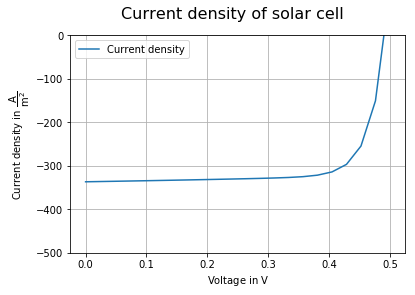

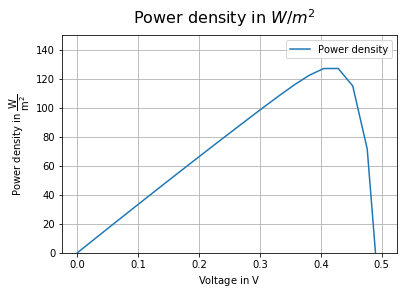

In [8]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of solar cell", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(-500,0)
plt.show()


# Power density
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Power density in $W/m^2$", fontsize=16)

axis.plot(voltage, -np.array(current_density)*np.array(voltage), label='Power density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Power density in $\mathrm{\dfrac{W}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(0,150)
plt.show()